Размер датасета (до очистки): (303, 14)

--- Информация о датасете ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

--- Пропуски ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0

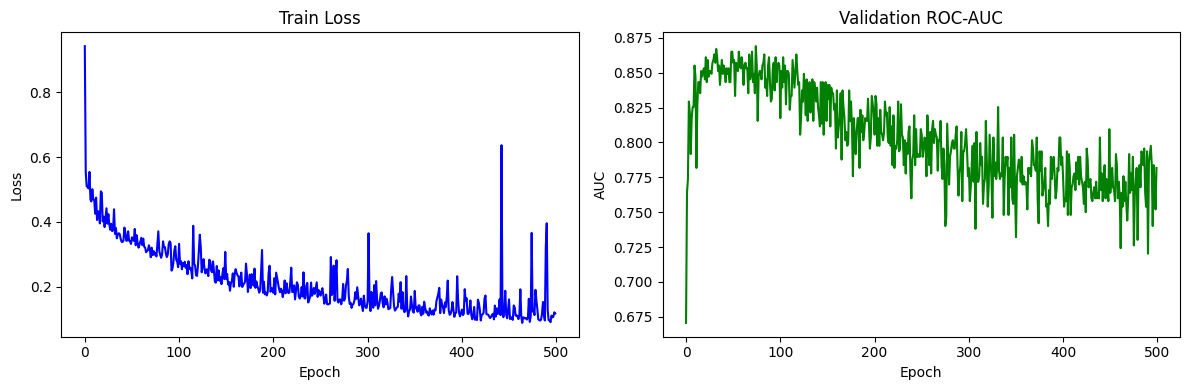

=== MLP — Test Metrics ===
Accuracy:  0.8000
Precision: 0.7500
Recall:    0.8571
F1:        0.8000
ROC-AUC:   0.9365

Confusion Matrix:
[[18  6]
 [ 3 18]]

=== Logistic Regression — Test Metrics ===
ROC-AUC: 0.9802
F1:      0.9524


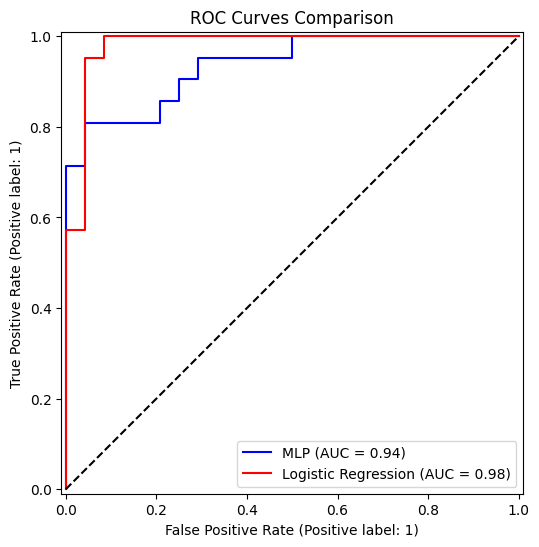


=== Бонус: Анализ расхождений моделей ===
Пациенты, где MLP ошибся, а LR прав (всего: 7):
     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
3   37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
11  56.0  0.0  2.0     140.0  294.0  0.0      2.0    153.0    0.0      1.3   
21  58.0  0.0  1.0     150.0  283.0  1.0      2.0    162.0    0.0      1.0   
24  60.0  1.0  4.0     130.0  206.0  0.0      2.0    132.0    1.0      2.4   
26  58.0  0.0  3.0     120.0  340.0  0.0      0.0    172.0    0.0      0.0   

    slope   ca  thal  target  
3     3.0  0.0   3.0       0  
11    2.0  0.0   3.0       0  
21    1.0  0.0   3.0       0  
24    2.0  2.0   7.0       1  
26    1.0  0.0   3.0       0  

Пациенты, где LR ошибся, а MLP прав (всего: 0):


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)

np.random.seed(42)

# ================= ШАГ 1. Загрузка данных =================
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "heart-disease/processed.cleveland.data"
)
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
raw = pd.read_csv(DATA_URL, header=None, names=COLUMNS, na_values="?")
print(f"Размер датасета (до очистки): {raw.shape}")

# Задание 1.1: Анализ датасета
print("\n--- Информация о датасете ---")
print(raw.info())
print("\n--- Пропуски ---")
print(raw.isnull().sum())

# Удаление строк с пропусками
raw = raw.dropna()
print(f"\nРазмер после удаления пропусков: {raw.shape}")

# Бинаризация целевой переменной
raw["target"] = (raw["target"] > 0).astype(int)
print("\n--- Распределение классов ---")
print(raw["target"].value_counts(normalize=True).round(3))
# Комментарий для отчета: Класс 0 (здоров) ~ 54.4%, Класс 1 (болен) ~ 45.6%.
# Дисбаланс присутствует, но он умеренный, не критический.

# ================= ШАГ 2. Предобработка =================
def preprocess_data(df):
    df = df.copy()
    y = df["target"].values.astype(np.int64)
    numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

    # TODO 2.1: One-hot encoding
    X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)

    X_num = df[numeric_cols].values.astype(np.float64)
    X = np.hstack([X_num, X_cat.values]).astype(np.float64)
    return X, y, numeric_cols

X, y, numeric_cols = preprocess_data(raw)
print(f"\nРазмерность признаков после encoding: {X.shape}")

# Разбиение и нормализация
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
num_features = len(numeric_cols)

# TODO 2.2: Fit на train, transform на все
scaler.fit(X_train[:, :num_features])
X_train[:, :num_features] = scaler.transform(X_train[:, :num_features])
X_val[:, :num_features] = scaler.transform(X_val[:, :num_features])
X_test[:, :num_features] = scaler.transform(X_test[:, :num_features])

# One-hot encoding меток
def to_one_hot(y, num_classes=2):
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

y_train_oh = to_one_hot(y_train)
y_val_oh = to_one_hot(y_val)

# ================= ШАГ 3. Функции активации =================
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def softmax(z):
    # TODO 3.1: Numerically stable softmax
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ================= ШАГ 4. Класс MLP =================
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        # TODO 4.1: Cross-entropy with epsilon
        epsilon = 1e-9
        loss = -np.sum(y_true * np.log(y_pred + epsilon)) / m
        return loss

    def backward(self, X, y_true):
        m = X.shape[0]
        dz2 = self.a2 - y_true
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_derivative(self.z1)

        # TODO 4.2: Gradients for W1 and b1
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        return self.forward(X)[:, 1]

# ================= ШАГ 5. Обучение =================
def train_mlp(model, X_train, y_train_oh, X_val, y_val,
              epochs=500, batch_size=32, verbose=True):
    history = {"train_loss": [], "val_auc": []}
    m = X_train.shape[0]
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train_oh[indices]
        epoch_loss = 0.0
        num_batches = 0

        for start in range(0, m, batch_size):
            X_batch = X_shuffled[start:start + batch_size]
            y_batch = y_shuffled[start:start + batch_size]
            y_pred = model.forward(X_batch)
            loss = model.compute_loss(y_pred, y_batch)
            model.backward(X_batch, y_batch)
            epoch_loss += loss
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        val_probs = model.predict_proba(X_val)
        val_auc = roc_auc_score(y_val, val_probs)

        history["train_loss"].append(avg_loss)
        history["val_auc"].append(val_auc)

        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch:4d} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}")
    return history

input_size = X_train.shape[1]
model = MLP(input_size=input_size, hidden_size=16, output_size=2, learning_rate=0.1)
history = train_mlp(model, X_train, y_train_oh, X_val, y_val, epochs=500, batch_size=32)

# TODO 5.1: Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], color='blue')
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["val_auc"], color='green')
axes[1].set_title("Validation ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
plt.tight_layout()
plt.show()

# ================= ШАГ 6. Оценка на тесте =================
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

print("=== MLP — Test Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# ================= ШАГ 7. Baseline =================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_lr_proba = lr_model.predict_proba(X_test)[:, 1]
y_lr_pred = lr_model.predict(X_test)

print("\n=== Logistic Regression — Test Metrics ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_lr_proba):.4f}")
print(f"F1:      {f1_score(y_test, y_lr_pred):.4f}")

# TODO 7.1: ROC-кривые
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_test_proba, name='MLP', ax=ax, color='blue')
RocCurveDisplay.from_predictions(y_test, y_lr_proba, name='Logistic Regression', ax=ax, color='red')
plt.title("ROC Curves Comparison")
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

# ================= ШАГ 8. Анализ ошибок =================
print("\n=== Анализ расхождений моделей ===")
# Где MLP ошибся, а LR угадал
mlp_wrong_lr_right_idx = np.where((y_test_pred != y_test) & (y_lr_pred == y_test))[0]
print(f"Пациенты, где MLP ошибся, а LR прав (всего: {len(mlp_wrong_lr_right_idx)}):")
if len(mlp_wrong_lr_right_idx) > 0:
    print(raw.iloc[mlp_wrong_lr_right_idx[:5]]) # Выводим до 5 штук

# Где LR ошибся, а MLP угадал
lr_wrong_mlp_right_idx = np.where((y_lr_pred != y_test) & (y_test_pred == y_test))[0]
print(f"\nПациенты, где LR ошибся, а MLP прав (всего: {len(lr_wrong_mlp_right_idx)}):")
if len(lr_wrong_mlp_right_idx) > 0:
    print(raw.iloc[lr_wrong_mlp_right_idx[:5]])